# 02 — Model comparison and selection

Six model families were trained on identical folds, the top three tuned with Optuna,
and every candidate re-evaluated under the same protocol. This notebook reads the
results and shows how the winner was chosen.

**The training itself is not run here.** It lives in `src/models/` and was executed
once (490 s, 13 MLflow runs); this notebook loads `artifacts/reports/` so it stays
reproducible in seconds rather than minutes.

Two rules govern every number below:

1. **The threshold is chosen inside each fold**, on an inner split of the training
   rows. Tuning it on validation would report an operating point that cannot exist in
   production.
2. **Accuracy is never used for selection.** A constant classifier scores 84.3%.

In [1]:
import sys, warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.common.logger import configure_logging
configure_logging("WARNING")

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 100, "figure.autolayout": True, "font.size": 9})

PLOTS = ROOT / "artifacts" / "plots"
REPORTS = ROOT / "artifacts" / "reports"
PLOTS.mkdir(parents=True, exist_ok=True)

def save(fig, name):
    fig.savefig(PLOTS / f"{name}.png", bbox_inches="tight", dpi=150)

pd.set_option("display.width", 200)

## 1 · The comparison table

In [2]:
results = pd.read_csv(REPORTS / "model_comparison.csv")
best_params = json.loads((REPORTS / "best_params.json").read_text())
results

,model,f1_declined,f1_std,recall_declined,precision_declined,roc_auc,pr_auc,brier,threshold,threshold_std
0,random_forest_tuned,0.3438,0.0315,0.6621,0.2327,0.6605,0.2913,0.1629,0.344,0.010
1,random_forest,0.3362,0.0311,0.5961,0.2364,0.6500,0.2780,0.1361,0.234,0.024
2,catboost_tuned,0.3228,0.0416,0.5608,0.2279,0.6446,0.2997,0.1930,0.440,0.028
3,xgboost_tuned,0.3208,0.0306,0.5761,0.2251,0.6463,0.2787,0.2197,0.488,0.031
4,xgboost,0.3078,0.0353,0.6865,0.2011,0.6312,0.2648,0.1793,0.264,0.077
5,catboost,0.3006,0.0192,0.5959,0.2075,0.6367,0.2749,0.1897,0.386,0.098
6,logistic_regression,0.2946,0.0272,0.5342,0.2044,0.6208,0.2478,0.2339,0.496,0.024
7,lightgbm,0.2910,0.0320,0.6308,0.1945,0.6210,0.2650,0.1910,0.332,0.103
8,mlp,0.2765,0.0081,0.5188,0.1919,0.5711,0.2169,0.2150,0.124,0.084


`_tuned` rows are the Optuna configurations re-evaluated under the same nested
cross-validation as the baselines — the search itself optimised PR-AUC, but selection
is reported on F1-Declined.

## 2 · F1-Declined, with fold dispersion

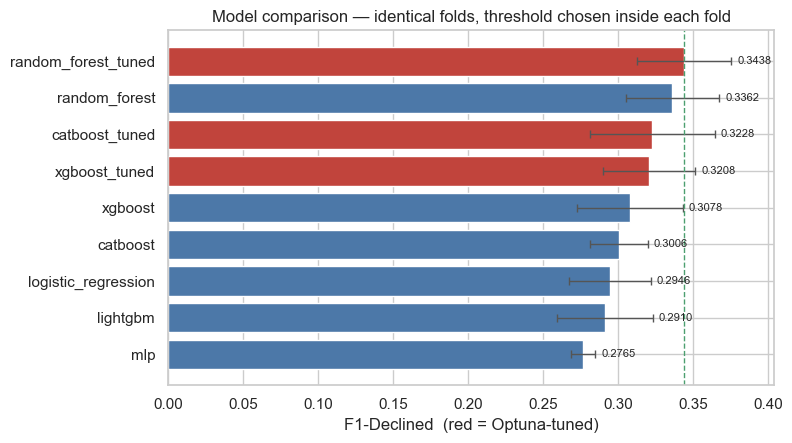

In [3]:
r = results.sort_values("f1_declined")
colors = ["#C1443C" if "_tuned" in m else "#4C78A8" for m in r.model]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(r.model, r.f1_declined, xerr=r.f1_std, color=colors,
        error_kw={"ecolor": "#555", "capsize": 3, "lw": 1})
for y, (v, s) in enumerate(zip(r.f1_declined, r.f1_std)):
    ax.text(v + s + 0.004, y, f"{v:.4f}", va="center", fontsize=8)
ax.axvline(r.f1_declined.max(), ls="--", c="#4C9F70", lw=1)
ax.set_xlabel("F1-Declined  (red = Optuna-tuned)")
ax.set_xlim(0, r.f1_declined.max() + 0.06)
ax.set_title("Model comparison — identical folds, threshold chosen inside each fold")
save(fig, "10_f1_comparison")

**The spread from best to worst is 6.7 F1 points** — 0.3438 for the tuned Random
Forest against 0.2765 for the MLP.

Two things this chart says that a single number cannot:

- **Tuning moved the winner by 0.008.** Random Forest went from 0.3362 to 0.3438. That
  is not a tuning failure; it is the diagnosis confirming itself. The bottleneck is the
  signal in the data, not the hyperparameters.
- **The error bars overlap almost everywhere.** On 453 positives, differences below
  ~0.03 F1 are not distinguishable from fold noise. Only the gap between the top group
  and the MLP is comfortably outside it.

## 3 · The metrics that F1 hides

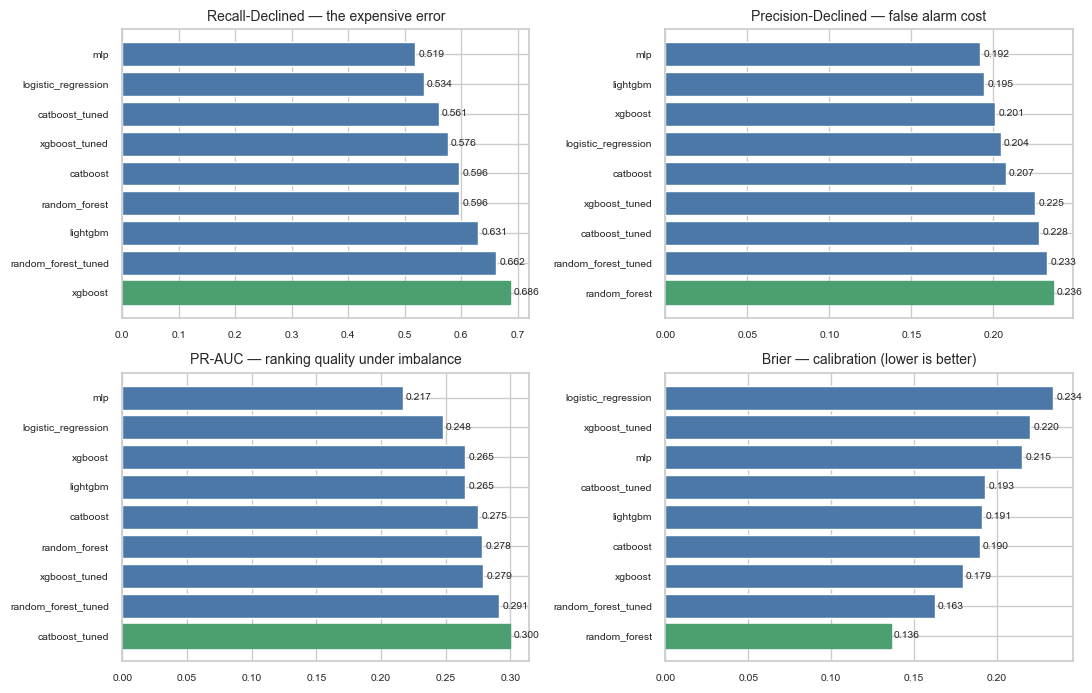

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
panels = [
    ("recall_declined", "Recall-Declined — the expensive error", "max"),
    ("precision_declined", "Precision-Declined — false alarm cost", "max"),
    ("pr_auc", "PR-AUC — ranking quality under imbalance", "max"),
    ("brier", "Brier — calibration (lower is better)", "min"),
]
for ax, (col, title, direction) in zip(axes.ravel(), panels):
    s = results.sort_values(col, ascending=(direction == "min"))
    best = s[col].iloc[-1] if direction == "max" else s[col].iloc[-1]
    bars = ax.barh(s.model, s[col], color="#4C78A8")
    winner_idx = s[col].idxmax() if direction == "max" else s[col].idxmin()
    for i, m in enumerate(s.model):
        if m == results.loc[winner_idx, "model"]:
            bars[i].set_color("#4C9F70")
    for y, v in enumerate(s[col]):
        ax.text(v * 1.01, y, f"{v:.3f}", va="center", fontsize=7.5)
    ax.set_title(title, fontsize=10)
    ax.tick_params(labelsize=7.5)
save(fig, "11_metric_panels")

No model wins everywhere, which is why selection needs a stated rule rather than a
glance:

- **Untuned XGBoost has the best recall** (0.687) — and the worst precision of the top
  group. It flags more, so it catches more.
- **Untuned Random Forest has the best calibration** (Brier 0.136), better than its own
  tuned version (0.163). Tuning bought F1 and recall at a small cost in calibration.
- **Tuned CatBoost has the best PR-AUC** (0.300) but the worst fold stability
  (±0.042).

Calibration is not a footnote here. **The HITL gate reads the score as a probability**:
thresholds of 0.30 and 0.70 mean nothing if the score is systematically inflated.

## 4 · Weighted decision matrix

In [5]:
from src.models.trainer import supports_native_missing

WEIGHTS = {
    "f1_declined":     (0.35, "max"),   # primary metric
    "recall_declined": (0.20, "max"),   # a missed decline is the expensive error
    "brier":           (0.15, "min"),   # the HITL gate reads the score as a probability
    "shap_quality":    (0.15, "max"),   # exact TreeSHAP feeds every explanation
    "f1_std":          (0.10, "min"),   # stability on 453 positives
    "native_missing":  (0.05, "max"),   # "not assessed" survives without imputation
}

cands = results[results.model.isin(
    ["random_forest_tuned", "random_forest", "xgboost_tuned", "catboost_tuned"])].copy()
base = lambda m: m.replace("_tuned", "")
cands["shap_quality"] = 1.0                       # all four are tree ensembles
cands["native_missing"] = cands.model.map(lambda m: float(supports_native_missing(base(m))))

score = pd.Series(0.0, index=cands.index)
for col, (w, direction) in WEIGHTS.items():
    v = cands[col].astype(float)
    rng = v.max() - v.min()
    norm = pd.Series(1.0, index=v.index) if rng == 0 else (
        (v - v.min()) / rng if direction == "max" else (v.max() - v) / rng)
    score += norm * w
cands["weighted_score"] = score.round(4)

out = cands[["model", "f1_declined", "recall_declined", "brier", "f1_std",
             "native_missing", "weighted_score"]].sort_values("weighted_score", ascending=False)
display(out)
print("WINNER:", out.iloc[0]["model"])

,model,f1_declined,recall_declined,brier,f1_std,native_missing,weighted_score
0,random_forest_tuned,0.3438,0.6621,0.1629,0.0315,0.0,0.8937
1,random_forest,0.3362,0.5961,0.1361,0.0311,0.0,0.6995
3,xgboost_tuned,0.3208,0.5761,0.2197,0.0306,1.0,0.3302
2,catboost_tuned,0.3228,0.5608,0.1930,0.0416,0.0,0.2283


WINNER: random_forest_tuned


**Random Forest (tuned) scores 0.89 against 0.33 for tuned XGBoost.**

The result does not depend on the weights. Random Forest beats tuned XGBoost on F1
(0.344 vs 0.321), on recall (0.662 vs 0.576) **and** on calibration (0.163 vs 0.220).
It loses only `native_missing` — the one criterion that favoured XGBoost — and still
wins. No defensible re-weighting reverses that.

**XGBoost was the expected winner and did not win.** The selection followed the
measurement.

One honest note: `shap_quality` is 1.0 for all four, since all are tree ensembles with
exact TreeSHAP. It carries weight in the matrix but **discriminates nothing here** —
it is recorded for traceability, not because it decided anything.

## 5 · What the selected model actually does

In [6]:
from src.data.loader import load_raw
from src.data.preprocessor import Preprocessor
from src.data.feature_engineer import FeatureEngineer
from src.models.evaluator import cross_validate
from src.models.trainer import make_factory

df = load_raw()
X = FeatureEngineer().fit_transform(Preprocessor().fit_transform(df))
y = X.pop("status")

params = best_params["random_forest"]
res = cross_validate(make_factory("random_forest", params=params), X, y, model_name="winner")

fm = res.fold_frame()
tn, fp, fn, tp = [int(fm[c].sum()) for c in
                  ("true_negatives", "false_positives", "false_negatives", "true_positives")]
total = tn + fp + fn + tp

cm = pd.DataFrame([[tn, fp], [fn, tp]],
                  index=["actually Completed", "actually Declined"],
                  columns=["predicted Approve", "predicted Decline"])
display(cm)
print(f"accuracy             {(tn+tp)/total:.4f}")
print(f"constant classifier  {(tn+fp)/total:.4f}   <-- predicting 'Completed' always")
print(f"recall               {res.mean('recall_declined'):.4f}   caught {tp}/{tp+fn} real declines")
print(f"precision            {res.mean('precision_declined'):.4f}   {tp}/{tp+fp} flagged were real")

,predicted Approve,predicted Decline
actually Completed,1438,989
actually Declined,153,300


accuracy             0.6035
constant classifier  0.8427   <-- predicting 'Completed' always
recall               0.6621   caught 300/453 real declines
precision            0.2327   300/1289 flagged were real


**Accuracy is 60%. That is worse than doing nothing (84.3%), and it is the intended
trade.**

To catch 300 of the 453 real declines, the model raises 989 false alarms. Every false
alarm costs accuracy that this project decided not to defend. Four flagged claims in
five are wrong.

That is the honest answer to *"can we trust the model?"* — **not as a decision-maker.**
Letting it decline autonomously would wrongly refuse 989 legitimate customers.

## 6 · But the ranking works — and that is the product

,n,declines,rate,lift
decile,,,,
0,288,22,0.076,0.486
1,288,30,0.104,0.662
2,288,29,0.101,0.640
3,288,22,0.076,0.486
4,288,30,0.104,0.662
5,288,40,0.139,0.883
6,288,48,0.167,1.060
7,288,66,0.229,1.457
8,288,80,0.278,1.766


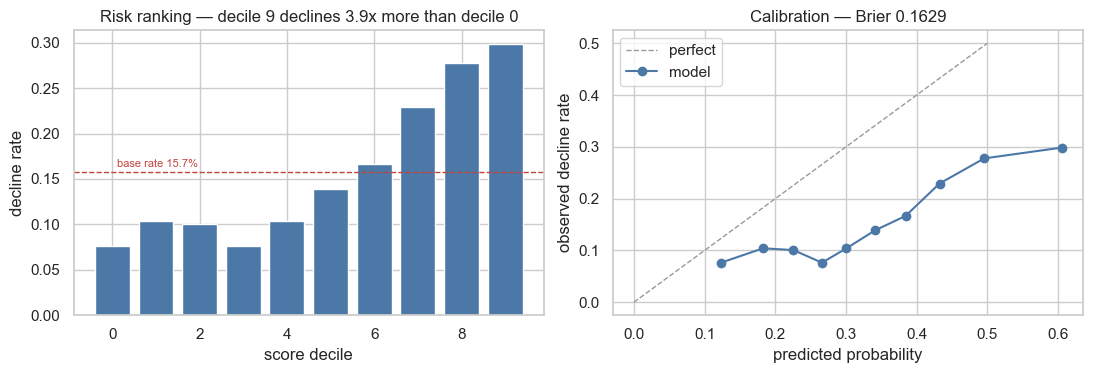

In [7]:
oof = pd.DataFrame({"score": res.oof_probabilities, "declined": res.oof_targets})
oof["decile"] = pd.qcut(oof.score, 10, labels=False, duplicates="drop")
g = oof.groupby("decile").agg(n=("declined", "size"), declines=("declined", "sum"),
                              rate=("declined", "mean"))
g["lift"] = g["rate"] / y.mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].bar(g.index, g["rate"], color="#4C78A8")
axes[0].axhline(y.mean(), ls="--", c="#C1443C", lw=1)
axes[0].text(0.1, y.mean() + 0.006, f"base rate {y.mean():.1%}", color="#C1443C", fontsize=8)
axes[0].set_xlabel("score decile")
axes[0].set_ylabel("decline rate")
axes[0].set_title("Risk ranking — decile 9 declines 3.9x more than decile 0")

from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(oof.declined, oof.score, n_bins=10, strategy="quantile")
axes[1].plot([0, 0.5], [0, 0.5], ls="--", c="#999", lw=1, label="perfect")
axes[1].plot(prob_pred, prob_true, "o-", color="#4C78A8", label="model")
axes[1].set_xlabel("predicted probability")
axes[1].set_ylabel("observed decline rate")
axes[1].set_title(f"Calibration — Brier {res.mean('brier'):.4f}")
axes[1].legend()
save(fig, "12_ranking_calibration")
display(g.round(3))

The decline rate climbs monotonically from decile 5 upward, and the top decile declines
at 29.9% against 7.6% in the bottom — a **3.9× spread**. Deciles 0–4 are noisy and all
sit below the base rate.

**The model is poor at deciding and adequate at ordering.** That is exactly what a
triage instrument needs to be.

The calibration curve matters for the next section: the HITL bands are probability
thresholds, so they only mean something if a predicted 0.30 really corresponds to a
30% decline risk.

## 7 · Human-in-the-Loop routing, measured

,claims,declines,decline_rate,share_volume,share_declines
score,,,,,
straight-through\n(<0.30),1295,118,0.091,0.450,0.260
human review\n(0.30-0.70),1563,322,0.206,0.543,0.711
expert\n(>=0.70),22,13,0.591,0.008,0.029


score distribution: min 0.034 | median 0.320 | max 0.809


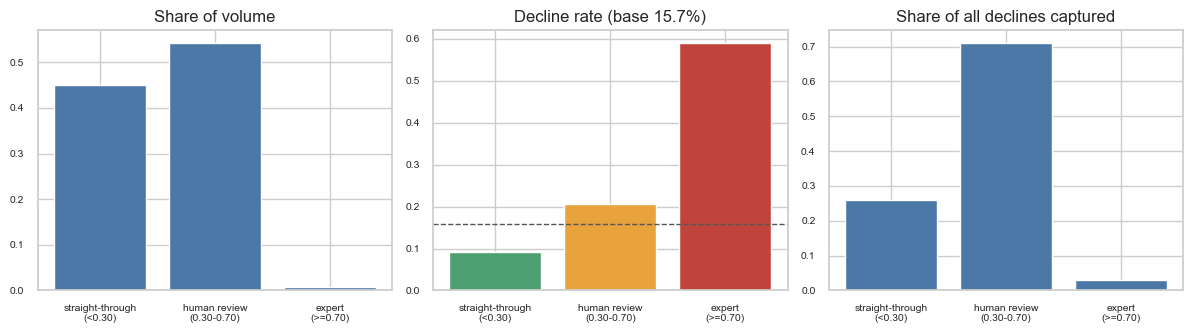

In [8]:
band = pd.cut(oof.score, [-0.01, 0.30, 0.70, 1.01],
              labels=["straight-through\n(<0.30)", "human review\n(0.30-0.70)", "expert\n(>=0.70)"])
route = oof.groupby(band, observed=False).agg(claims=("declined", "size"),
                                              declines=("declined", "sum"),
                                              decline_rate=("declined", "mean"))
route["share_volume"] = route["claims"] / len(oof)
route["share_declines"] = route["declines"] / oof.declined.sum()

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
axes[0].bar(route.index, route.share_volume, color="#4C78A8")
axes[0].set_title("Share of volume")
axes[1].bar(route.index, route.decline_rate, color=["#4C9F70", "#E8A33D", "#C1443C"])
axes[1].axhline(y.mean(), ls="--", c="#555", lw=1)
axes[1].set_title(f"Decline rate (base {y.mean():.1%})")
axes[2].bar(route.index, route.share_declines, color="#4C78A8")
axes[2].set_title("Share of all declines captured")
for ax in axes:
    ax.tick_params(labelsize=7.5)
save(fig, "13_hitl_routing")
display(route.round(3))
print(f"score distribution: min {oof.score.min():.3f} | median {oof.score.median():.3f} "
      f"| max {oof.score.max():.3f}")

| Band | Volume | Decline rate | Share of declines |
|---|---|---|---|
| straight-through (<0.30) | 45.0% | **9.1%** | 26.0% |
| human review (0.30–0.70) | 54.3% | 20.6% | 71.1% |
| expert (≥0.70) | 0.8% | **59.1%** | 2.9% |

**The routing works.** The straight-through band declines at 9.1% against a 15.7% base
rate — a little over half the risk — and holds only 26% of all declines. The expert
band is 22 claims but declines at 59.1%, a **3.8× lift**.

The selected threshold is 0.344 ± **0.010** across folds. That stability is the check
that the operating point is not fitted to one particular split.

**The system never auto-declines.** These bands route; a human decides every adverse
outcome.

## 8 · SHAP — the evidence the explanations are built from

In [9]:
import shap
from src.models.trainer import build_model

model = build_model("random_forest", params=params)
model.fit(X, y)

# TreeExplainer needs the estimator, not the pipeline, so the imputation step is applied
# first — exactly what the pipeline does internally before the forest sees a row.
imputer, forest = model.named_steps["impute"], model.named_steps["clf"]
X_imputed = pd.DataFrame(imputer.transform(X), columns=X.columns)

sample = X_imputed.sample(400, random_state=42)
explainer = shap.TreeExplainer(forest)
values = explainer.shap_values(sample)

# Binary classifiers return per-class attributions; the Declined class is index 1.
sv = values[:, :, 1] if isinstance(values, np.ndarray) and values.ndim == 3 else values[1]
print("shap values:", sv.shape)

shap values: (400, 37)


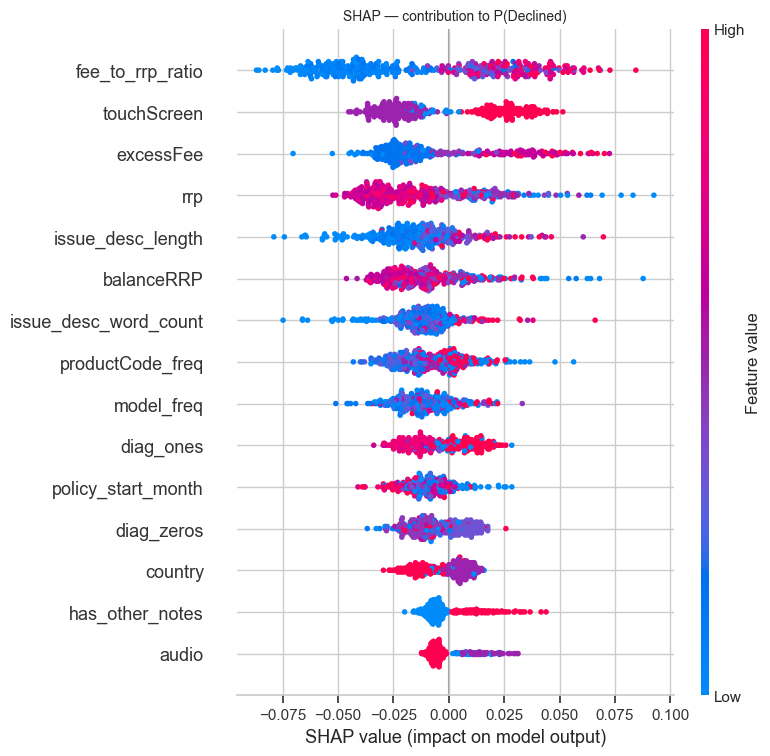

In [10]:
fig = plt.figure(figsize=(8, 6))
shap.summary_plot(sv, sample, max_display=15, show=False)
plt.title("SHAP — contribution to P(Declined)", fontsize=10)
save(plt.gcf(), "14_shap_summary")
plt.show()

top 15 features by mean |SHAP|:
fee_to_rrp_ratio         0.03640
touchScreen              0.02480
excessFee                0.02457
rrp                      0.02350
issue_desc_length        0.01859
balanceRRP               0.01766
issue_desc_word_count    0.01371
productCode_freq         0.01361
model_freq               0.01326
diag_ones                0.01182
policy_start_month       0.01129
diag_zeros               0.01046
country                  0.00919
has_other_notes          0.00852
audio                    0.00769

engineered features carry 39.5% of total attribution
of the top 10, 4 are engineered


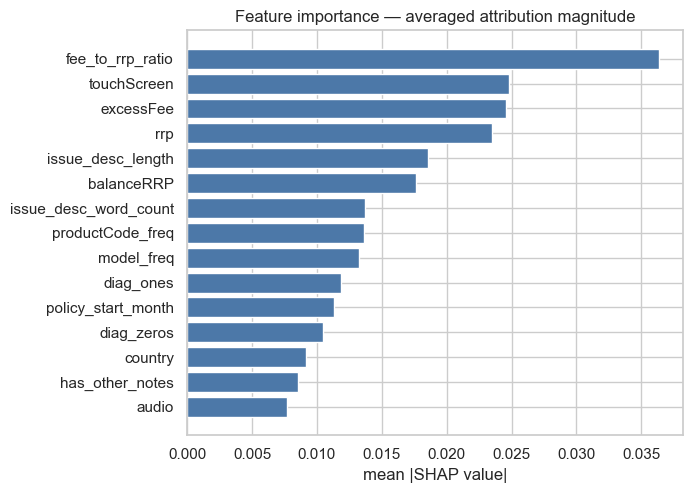

In [11]:
importance = (pd.Series(np.abs(sv).mean(axis=0), index=sample.columns)
              .sort_values(ascending=False))
top = importance.head(15)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(top.index[::-1], top.values[::-1], color="#4C78A8")
ax.set_xlabel("mean |SHAP value|")
ax.set_title("Feature importance — averaged attribution magnitude")
save(fig, "15_shap_importance")

print("top 15 features by mean |SHAP|:")
print(top.round(5).to_string())

derived = ["fee_to_rrp_ratio", "balance_ratio", "remaining_balance_ratio",
           "contract_duration_months", "is_mandatory_policy", "payment_mode",
           "diag_completeness", "diag_ones", "diag_zeros",
           "issue_desc_length", "issue_desc_word_count",
           "policy_duration_days", "days_purchase_to_policy"]
share = importance[importance.index.isin(derived)].sum() / importance.sum()
print(f"\nengineered features carry {share:.1%} of total attribution")
print(f"of the top 10, {sum(f in derived for f in importance.head(10).index)} are engineered")

This plot is the raw material of the whole GenAI layer. Every customer explanation,
every adjuster justification, every auditor record is a rendering of these numbers —
the LLM converts attributions into sentences and invents nothing.

`TreeExplainer` gives **exact** Shapley values for tree ensembles in polynomial time,
milliseconds per claim, which is what makes it usable inside the request path. LIME was
rejected because its local surrogates change between runs, and an audit trail that
changes when re-run is not an audit trail.

## 9 · What was decided, and on what evidence

| Decision | Evidence |
|---|---|
| **Random Forest (tuned)** as the production model | Weighted score 0.89 vs 0.33; wins F1, recall and calibration outright |
| XGBoost rejected despite being the expected winner | F1 0.321 vs 0.344, recall 0.576 vs 0.662, Brier 0.220 vs 0.163 |
| Neural networks rejected | MLP finishes last: F1 0.2765, ROC-AUC 0.5711 |
| Accuracy excluded as a metric | A constant classifier scores 84.3%; the selected model scores 60.4% |
| Tuning objective is PR-AUC, not F1 | Tuning on F1 *degraded* Random Forest (0.336 → 0.317); the in-sample threshold it needs does not transfer |
| Calibration is a selection criterion | The HITL gate reads the score as a probability |
| Human-in-the-Loop is mandatory | Precision 0.233 — four flags in five are wrong |
| Positioned as triage, not adjudication | Ranking works (3.9× decile lift); point classification does not |

**The open question that limits this work:** what is the business cost ratio between a
false approval and a false decline? The 0.30 / 0.70 bands were set before a model
existed, and F1 assumes both errors cost the same — which is almost certainly untrue.
That number is not derivable from the data; it belongs to the business.